# Licht An / Licht Aus Klassifikator mit MFCC

In diesem Notebook bauen wir ein Audio-Klassifikator fuer die Sprachbefehle "licht_an" und "licht_aus". Das Notebook vergleicht mehrere Modelle, vergleicht zwei Trainings-Setups und zeigt auch, was mit der dritten Klasse "unknown" passiert.

Wichtig: Die Klasse "unknown" ist sehr klein. Darum ist sie vor allem ein Robustheits- und Fehlbefehlstest, nicht der Haupttreiber fuer das Training.


## Fragestellung und Versuchsaufbau

Wir vergleichen zwei Varianten:

1. Binary Setup: nur "licht_an" und "licht_aus" im Training, unknown bleibt ausserhalb des Trainings und wird nur zum Testen benutzt.
2. Three-Class Setup: "licht_an", "licht_aus" und "unknown" werden gemeinsam trainiert und mit gruppenbewussten Splits ausgewertet.

Als Merkmale verwenden wir weiterhin MFCC. Als Alternative probieren wir Log-Mel-Features mit derselben Auswertungslogik.

Damit wir keine Leckage bekommen, versuchen wir Dateien mit gleicher Herkunft in derselben Split-Gruppe zu halten.


## Daten einlesen

Die Klassenordner werden zu einer Tabelle zusammengefasst und per Datei geladen.


In [130]:
from pathlib import Path
import random
import warnings

import librosa
import librosa.display as ldisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_predict
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from sklearn.model_selection import StratifiedGroupKFold

    def make_cv(n_splits, random_state=42):
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
except ImportError:
    from sklearn.model_selection import GroupKFold

    def make_cv(n_splits, random_state=42):
        return GroupKFold(n_splits=n_splits)

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_ROOT = Path('data')
AUDIO_EXTENSIONS = {'.wav', '.mp3', '.m4a', '.ogg', '.flac'}
KNOWN_LABELS = ['licht_an', 'licht_aus']
ALL_LABELS = ['licht_an', 'licht_aus', 'unknown']
LABEL_TO_INDEX_BINARY = {'licht_an': 0, 'licht_aus': 1}
LABEL_TO_INDEX_THREE = {'licht_an': 0, 'licht_aus': 1, 'unknown': 2}
INDEX_TO_LABEL_BINARY = {v: k for k, v in LABEL_TO_INDEX_BINARY.items()}
INDEX_TO_LABEL_THREE = {v: k for k, v in LABEL_TO_INDEX_THREE.items()}

SR = 16_000
TARGET_SECONDS = 1.0
TARGET_SAMPLES = int(SR * TARGET_SECONDS)
N_MFCC = 13
N_MELS = 40
N_FFT = 512
HOP_LENGTH = 160
WIN_LENGTH = 400
FMIN = 50
FMAX = 4_000

FEATURE_SPECS = {
    'mfcc_stats': 'mfcc',
    'logmel_stats': 'logmel',
}


## Audio und Features

Hier werden die WAV-Dateien auf eine feste Laenge gebracht und in MFCC oder Log-Mel Features umgewandelt.


In [131]:

def list_audio_files(folder):
    if not folder.exists():
        return []
    return sorted(
        [
            path
            for path in folder.rglob('*')
            if path.is_file() and path.suffix.lower() in AUDIO_EXTENSIONS
        ]
    )


def infer_group_id(path):
    return Path(path).stem.lower()


def collect_dataset(root):
    # Alle Audio-Dateien aus den Klassenordnern in eine Tabelle laden.
    records = []
    for label in ALL_LABELS:
        folder = root / label
        if not folder.exists():
            continue
        for path in list_audio_files(folder):
            records.append(
                {
                    'path': str(path),
                    'label': label,
                    'group': infer_group_id(path),
                    'filename': path.name,
                }
            )
    return pd.DataFrame(records)


df = collect_dataset(DATA_ROOT)
df = df.sort_values(['label', 'filename']).reset_index(drop=True)
print('Dateien pro Klasse:')
print(df['label'].value_counts())
print(f'Gesamt: {len(df)} Dateien')
display(df.head())


Dateien pro Klasse:
label
licht_an     165
licht_aus    165
unknown      134
Name: count, dtype: int64
Gesamt: 464 Dateien


,path,label,group,filename
0,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,minimax_2026-05-05_16_43_17_levi_0189_licht_an,MiniMax_2026-05-05_16_43_17_Levi_0189_licht_an...
1,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,minimax_2026-05-05_16_43_17_levi_frequenz_0123...,MiniMax_2026-05-05_16_43_17_Levi_Frequenz_0123...
2,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,minimax_2026-05-05_16_43_17_levi_laut_0129_lic...,MiniMax_2026-05-05_16_43_17_Levi_Laut_0129_lic...
3,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,minimax_2026-05-05_16_43_17_levi_rauschen_0111...,MiniMax_2026-05-05_16_43_17_Levi_Rauschen_0111...
4,data\licht_an\MiniMax_2026-05-05_16_43_17_Levi...,licht_an,minimax_2026-05-05_16_43_17_levi_echo_0117_lic...,MiniMax_2026-05-05_16_43_17_Levi_echo_0117_lic...


In [132]:
def load_audio(path, sr=SR, target_samples=TARGET_SAMPLES):
    # Audio auf eine feste Laenge bringen, damit alle Clips direkt vergleichbar sind.
    audio, _ = librosa.load(path, sr=sr, mono=True)
    audio = np.nan_to_num(audio).astype(np.float32)

    if len(audio) == 0:
        return np.zeros(target_samples, dtype=np.float32)

    if len(audio) > target_samples:
        frame = min(1024, len(audio))
        energy = np.convolve(audio ** 2, np.ones(frame, dtype=np.float32), mode='same')
        center = int(np.argmax(energy))
        start = max(0, center - target_samples // 2)
        end = start + target_samples
        if end > len(audio):
            end = len(audio)
            start = end - target_samples
        audio = audio[start:end]
    elif len(audio) < target_samples:
        audio = np.pad(audio, (0, target_samples - len(audio)))

    peak = float(np.max(np.abs(audio)))
    if peak > 0:
        audio = audio / peak

    return audio.astype(np.float32)


def compute_base_map(audio, feature_kind='mfcc'):
    # Erst Log-Mel berechnen und daraus entweder MFCC oder Log-Mel als Feature ableiten.
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0,
    )
    log_mel = librosa.power_to_db(mel + 1e-10)

    if feature_kind == 'mfcc':
        return librosa.feature.mfcc(S=log_mel, n_mfcc=N_MFCC)
    if feature_kind == 'logmel':
        return log_mel
    raise ValueError(f'Unbekannter Feature-Typ: {feature_kind}')


def summarize_feature_map(feature_map):
    # Zeitliche Statistik ueber MFCC/Log-Mel und ihre Ableitungen bilden.
    delta = librosa.feature.delta(feature_map)
    delta2 = librosa.feature.delta(feature_map, order=2)
    vector = np.concatenate(
        [
            feature_map.mean(axis=1),
            feature_map.std(axis=1),
            delta.mean(axis=1),
            delta.std(axis=1),
            delta2.mean(axis=1),
            delta2.std(axis=1),
        ]
    )
    return vector.astype(np.float32)


def build_feature_matrix(audio_series, feature_kind):
    # Aus jeder Aufnahme einen festen Feature-Vektor machen.
    feature_vectors = []
    for audio in audio_series:
        feature_vectors.append(summarize_feature_map(compute_base_map(audio, feature_kind=feature_kind)))
    return np.vstack(feature_vectors)


df['audio'] = [load_audio(path) for path in df['path']]
print('Audio geladen:', len(df))


Audio geladen: 464


## Erste Visualisierung

Jetzt schauen wir uns Klassenverteilung und Beispielsignale an.


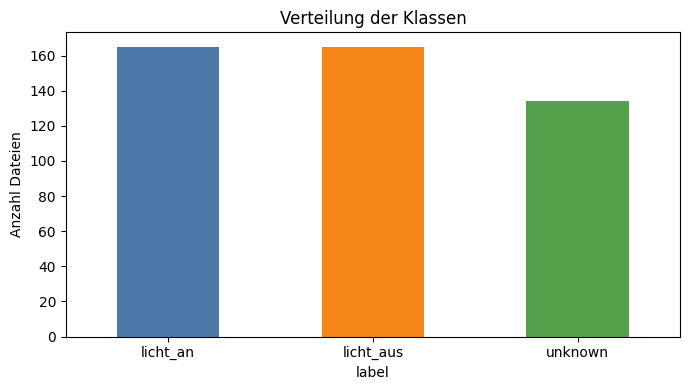

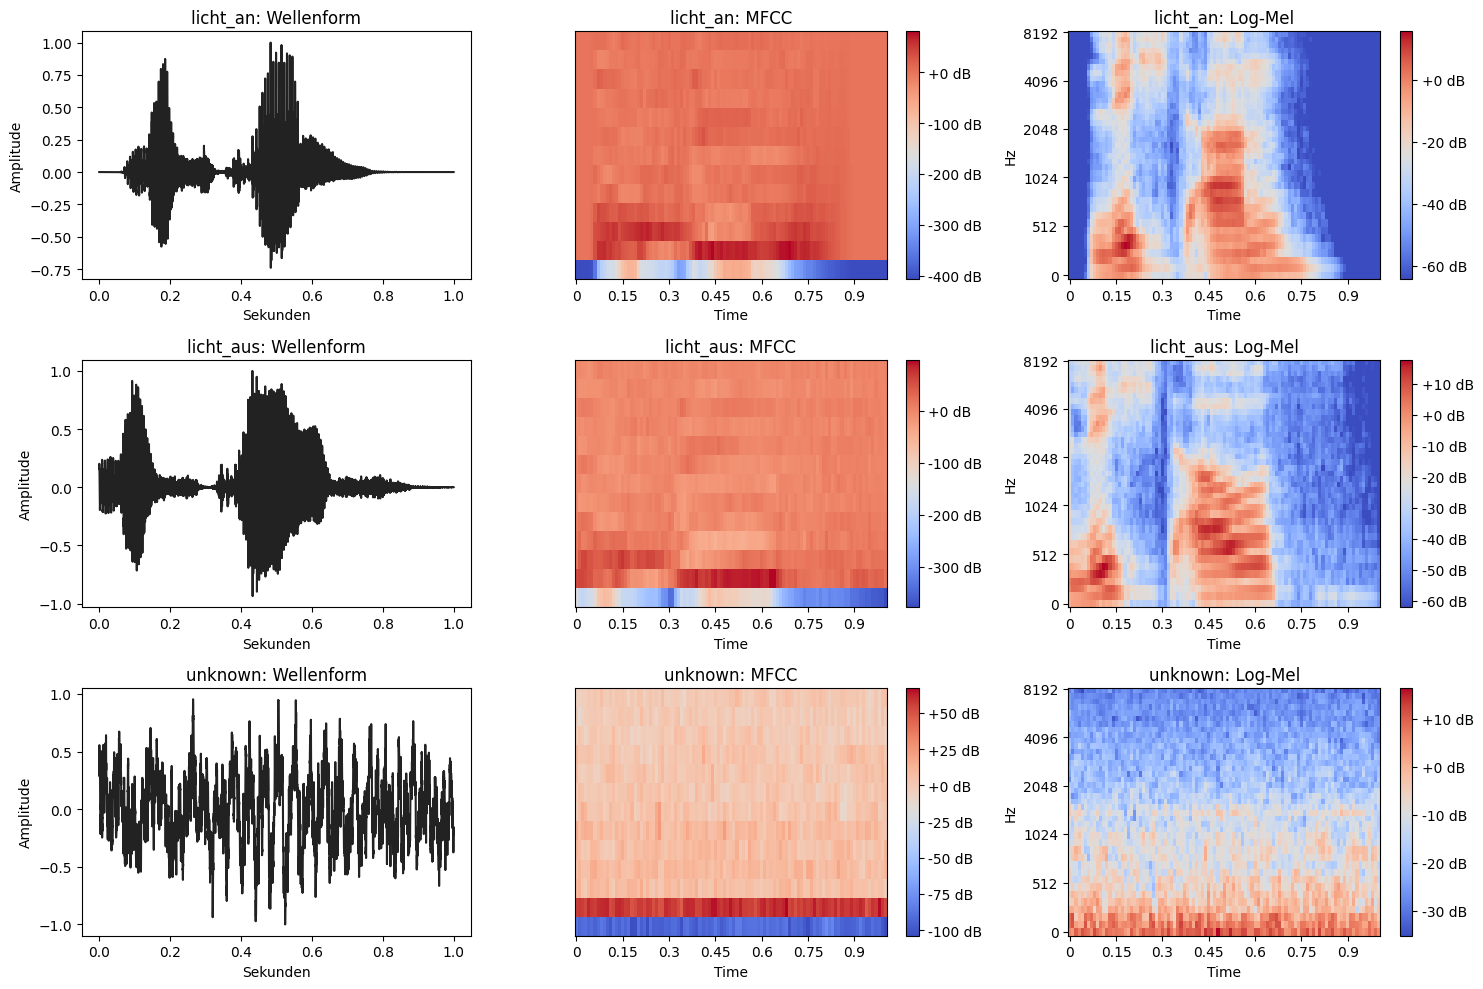

In [133]:
def plot_dataset_overview(frame):
    # Schnellcheck: Wie viele Beispiele gibt es pro Klasse?
    class_counts = frame['label'].value_counts().reindex(ALL_LABELS)
    plt.figure(figsize=(7, 4))
    class_counts.plot(kind='bar', color=['#4C78A8', '#F58518', '#54A24B'])
    plt.title('Verteilung der Klassen')
    plt.ylabel('Anzahl Dateien')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


plot_dataset_overview(df)


def plot_example_grid(frame):
    # Beispielhafte Signale und Features pro Klasse nebeneinander zeigen.
    fig, axes = plt.subplots(len(ALL_LABELS), 3, figsize=(15, 10))
    for row_index, label in enumerate(ALL_LABELS):
        sample = frame[frame['label'] == label].iloc[0]
        audio = sample['audio']
        mfcc_map = compute_base_map(audio, feature_kind='mfcc')
        logmel_map = compute_base_map(audio, feature_kind='logmel')

        axes[row_index, 0].plot(np.linspace(0, TARGET_SECONDS, len(audio)), audio, color='#222222')
        axes[row_index, 0].set_title(f'{label}: Wellenform')
        axes[row_index, 0].set_xlabel('Sekunden')
        axes[row_index, 0].set_ylabel('Amplitude')

        img1 = ldisplay.specshow(mfcc_map, sr=SR, hop_length=HOP_LENGTH, x_axis='time', ax=axes[row_index, 1])
        axes[row_index, 1].set_title(f'{label}: MFCC')
        fig.colorbar(img1, ax=axes[row_index, 1], format='%+2.0f dB')

        img2 = ldisplay.specshow(logmel_map, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=axes[row_index, 2])
        axes[row_index, 2].set_title(f'{label}: Log-Mel')
        fig.colorbar(img2, ax=axes[row_index, 2], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()


plot_example_grid(df)


## Modelle und Auswertung

Diese Zelle definiert die Kandidatenmodelle sowie die Evaluationslogik fuer Binary und Three-Class.


In [134]:
def make_models(random_state=RANDOM_STATE):
    # Vier klassische Baselines, damit wir verschiedene Modellfamilien vergleichen koennen.
    return {
        'logreg': Pipeline(
            [
                ('scaler', StandardScaler()),
                (
                    'clf',
                    LogisticRegression(
                        max_iter=3000,
                        class_weight='balanced',
                        random_state=random_state,
                    ),
                ),
            ]
        ),
        'svm_rbf': Pipeline(
            [
                ('scaler', StandardScaler()),
                (
                    'clf',
                    SVC(
                        kernel='rbf',
                        probability=True,
                        class_weight='balanced',
                        random_state=random_state,
                    ),
                ),
            ]
        ),
        'random_forest': RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            random_state=random_state,
        ),
        'mlp': Pipeline(
            [
                ('scaler', StandardScaler()),
                (
                    'clf',
                    MLPClassifier(
                        hidden_layer_sizes=(128, 64),
                        activation='relu',
                        alpha=1e-4,
                        max_iter=600,
                        early_stopping=True,
                        random_state=random_state,
                    ),
                ),
            ]
        ),
    }


def make_splitter(y, groups, max_splits=5):
    # Folds so waehlen, dass Klassen- und Gruppeninfos respektiert werden.
    class_counts = pd.Series(y).value_counts()
    group_count = pd.Series(groups).nunique()
    n_splits = int(min(max_splits, class_counts.min(), group_count))
    n_splits = max(n_splits, 2)
    return make_cv(n_splits, random_state=RANDOM_STATE)


def evaluate_binary_model(estimator, X_known, y_known, groups_known, X_unknown):
    # Binary-Setup: nur licht_an / licht_aus trainieren und unknown separat pruefen.
    splitter = make_splitter(y_known, groups_known)
    oof_proba = cross_val_predict(
        estimator,
        X_known,
        y_known,
        cv=splitter,
        groups=groups_known,
        method='predict_proba',
    )
    oof_pred = np.argmax(oof_proba, axis=1)
    oof_conf = np.max(oof_proba, axis=1)
    # Schwellwert aus den bekannten Beispielen ableiten, um unsichere Vorhersagen zu erkennen.
    threshold = float(np.quantile(oof_conf, 0.10))

    fold_unknown_proba = []
    for train_index, _ in splitter.split(X_known, y_known, groups_known):
        fitted = clone(estimator)
        fitted.fit(X_known[train_index], y_known[train_index])
        fold_unknown_proba.append(fitted.predict_proba(X_unknown))

    unknown_proba = np.mean(fold_unknown_proba, axis=0)
    unknown_pred = np.argmax(unknown_proba, axis=1)
    unknown_conf = np.max(unknown_proba, axis=1)

    return {
        'accuracy': accuracy_score(y_known, oof_pred),
        'macro_f1': f1_score(y_known, oof_pred, average='macro'),
        'confusion_matrix': confusion_matrix(y_known, oof_pred),
        'classification_report': classification_report(
            y_known,
            oof_pred,
            target_names=[INDEX_TO_LABEL_BINARY[i] for i in sorted(INDEX_TO_LABEL_BINARY)],
            output_dict=True,
            zero_division=0,
        ),
        'known_pred': oof_pred,
        'known_proba': oof_proba,
        'known_conf': oof_conf,
        'threshold': threshold,
        'unknown_pred': unknown_pred,
        'unknown_proba': unknown_proba,
        'unknown_conf': unknown_conf,
        'unknown_accept_rate': float(np.mean(unknown_conf >= threshold)),
        'unknown_reject_rate': float(np.mean(unknown_conf < threshold)),
        'unknown_mean_conf': float(np.mean(unknown_conf)),
    }


def evaluate_three_class_model(estimator, X_all, y_all, groups_all):
    # Three-Class-Setup: unknown wird direkt als eigene Klasse mittrainiert.
    splitter = make_splitter(y_all, groups_all)
    oof_proba = cross_val_predict(
        estimator,
        X_all,
        y_all,
        cv=splitter,
        groups=groups_all,
        method='predict_proba',
    )
    oof_pred = np.argmax(oof_proba, axis=1)
    oof_conf = np.max(oof_proba, axis=1)
    return {
        'accuracy': accuracy_score(y_all, oof_pred),
        'macro_f1': f1_score(y_all, oof_pred, average='macro'),
        'confusion_matrix': confusion_matrix(y_all, oof_pred),
        'classification_report': classification_report(
            y_all,
            oof_pred,
            target_names=[INDEX_TO_LABEL_THREE[i] for i in sorted(INDEX_TO_LABEL_THREE)],
            output_dict=True,
            zero_division=0,
        ),
        'known_pred': oof_pred,
        'known_proba': oof_proba,
        'known_conf': oof_conf,
    }


def run_experiments(feature_name, feature_kind):
    # Fuer ein Feature-Set alle Modelle und beide Aufgaben einmal durchrechnen.
    feature_matrix = build_feature_matrix(df['audio'], feature_kind=feature_kind)

    known_mask = df['label'].isin(KNOWN_LABELS)
    unknown_mask = df['label'] == 'unknown'

    known_df = df.loc[known_mask].reset_index(drop=True)
    unknown_df = df.loc[unknown_mask].reset_index(drop=True)

    X_known = feature_matrix[known_mask.to_numpy()]
    X_unknown = feature_matrix[unknown_mask.to_numpy()]
    X_all = feature_matrix

    y_known = known_df['label'].map(LABEL_TO_INDEX_BINARY).to_numpy()
    y_all = df['label'].map(LABEL_TO_INDEX_THREE).to_numpy()

    groups_known = known_df['group'].to_numpy()
    groups_all = df['group'].to_numpy()

    # Alle Kandidatenmodelle durchtesten.
    model_bank = make_models()
    results = []
    detailed = {}

    for model_name, model in model_bank.items():
        binary_result = evaluate_binary_model(model, X_known, y_known, groups_known, X_unknown)
        detailed[('binary', model_name)] = binary_result
        results.append(
            {
                'task': 'binary',
                'feature': feature_name,
                'model': model_name,
                'accuracy': binary_result['accuracy'],
                'macro_f1': binary_result['macro_f1'],
                'unknown_accept_rate': binary_result['unknown_accept_rate'],
                'unknown_reject_rate': binary_result['unknown_reject_rate'],
                'unknown_mean_conf': binary_result['unknown_mean_conf'],
                'threshold': binary_result['threshold'],
            }
        )

        three_result = evaluate_three_class_model(model, X_all, y_all, groups_all)
        detailed[('three_class', model_name)] = three_result
        results.append(
            {
                'task': 'three_class',
                'feature': feature_name,
                'model': model_name,
                'accuracy': three_result['accuracy'],
                'macro_f1': three_result['macro_f1'],
                'unknown_accept_rate': np.nan,
                'unknown_reject_rate': np.nan,
                'unknown_mean_conf': np.nan,
                'threshold': np.nan,
            }
        )

    return pd.DataFrame(results), detailed, {
        'feature_matrix': feature_matrix,
        'known_df': known_df,
        'unknown_df': unknown_df,
        'X_known': X_known,
        'X_unknown': X_unknown,
        'X_all': X_all,
        'y_known': y_known,
        'y_all': y_all,
        'groups_known': groups_known,
        'groups_all': groups_all,
    }


## Vergleichslauf

Hier werden alle Modelle fuer beide Feature-Varianten durchgerechnet.


In [135]:
# Beide Feature-Varianten sammeln und die Ergebnisse zusammenfuehren.
all_rows = []
all_details = {}
all_contexts = {}

for feature_name, feature_kind in FEATURE_SPECS.items():
    summary_frame, details, context = run_experiments(feature_name, feature_kind)
    all_rows.append(summary_frame)
    all_details[feature_name] = details
    all_contexts[feature_name] = context

results_df = pd.concat(all_rows, ignore_index=True)
results_df['accuracy'] = results_df['accuracy'].round(4)
results_df['macro_f1'] = results_df['macro_f1'].round(4)
results_df['unknown_accept_rate'] = results_df['unknown_accept_rate'].round(4)
results_df['unknown_reject_rate'] = results_df['unknown_reject_rate'].round(4)
results_df['unknown_mean_conf'] = results_df['unknown_mean_conf'].round(4)
results_df['threshold'] = results_df['threshold'].round(4)

display(results_df.sort_values(['task', 'feature', 'macro_f1'], ascending=[True, True, False]))


,task,feature,model,accuracy,macro_f1,unknown_accept_rate,unknown_reject_rate,unknown_mean_conf,threshold
10,binary,logmel_stats,svm_rbf,0.9152,0.9151,0.7985,0.2015,0.8047,0.7182
12,binary,logmel_stats,random_forest,0.9000,0.8999,0.3806,0.6194,0.5889,0.5953
8,binary,logmel_stats,logreg,0.8818,0.8818,0.5970,0.4030,0.8017,0.7785
14,binary,logmel_stats,mlp,0.8758,0.8757,0.7910,0.2090,0.7153,0.5864
4,binary,mfcc_stats,random_forest,0.9091,0.9090,0.5373,0.4627,0.5706,0.5589
2,binary,mfcc_stats,svm_rbf,0.9030,0.9030,0.6045,0.3955,0.7327,0.6994
6,binary,mfcc_stats,mlp,0.8576,0.8574,0.9478,0.0522,0.7952,0.5754
0,binary,mfcc_stats,logreg,0.8545,0.8545,0.6866,0.3134,0.8166,0.7383
11,three_class,logmel_stats,svm_rbf,0.9159,0.9183,NaN,NaN,NaN,NaN
13,three_class,logmel_stats,random_forest,0.8879,0.8912,NaN,NaN,NaN,NaN


## Ergebnisvergleich

Die Tabelle und die Balkendiagramme zeigen, welches Setup am besten abschneidet.


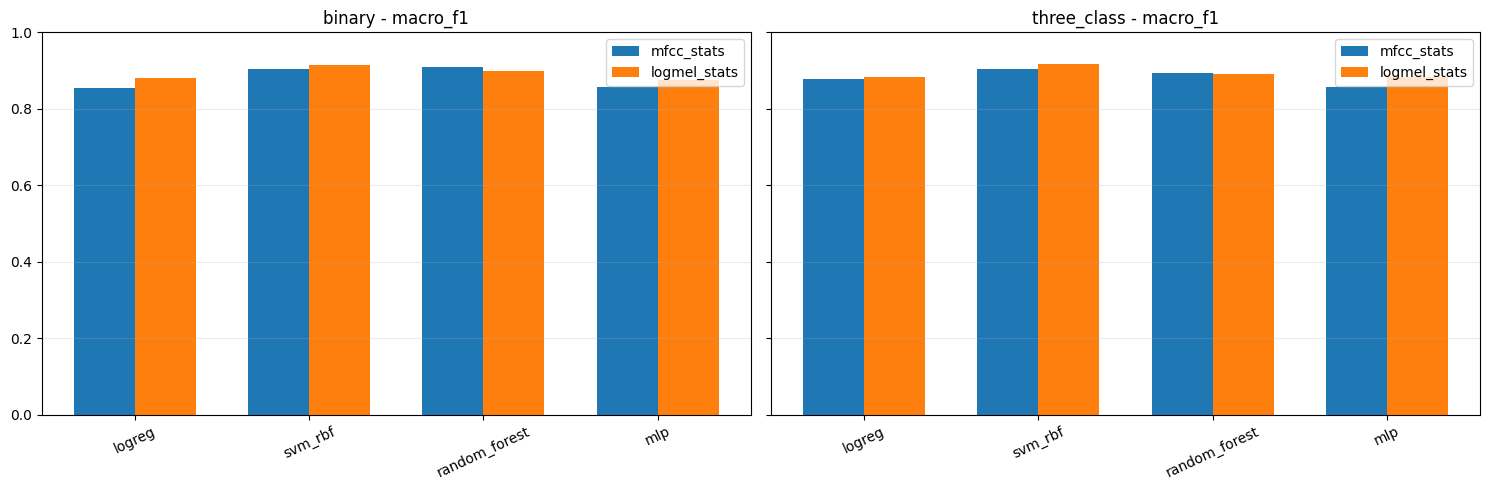

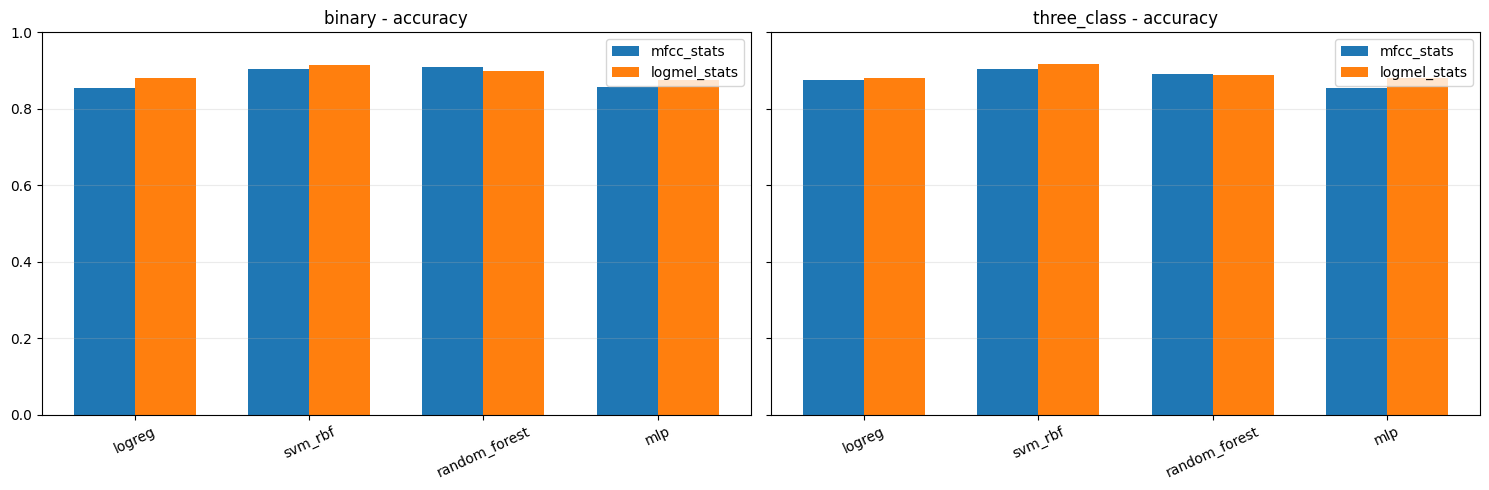

In [136]:
def plot_score_comparison(frame, score_name='macro_f1'):
    # Balkendiagramm fuer den direkten Modellvergleich.
    tasks = ['binary', 'three_class']
    features = list(FEATURE_SPECS.keys())
    models = list(make_models().keys())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for axis, task in zip(axes, tasks):
        subset = frame[frame['task'] == task]
        x = np.arange(len(models))
        width = 0.35

        for offset, feature in enumerate(features):
            values = [
                subset[(subset['model'] == model) & (subset['feature'] == feature)][score_name].iloc[0]
                for model in models
            ]
            axis.bar(x + (offset - 0.5) * width, values, width=width, label=feature)

        axis.set_title(f'{task} - {score_name}')
        axis.set_xticks(x)
        axis.set_xticklabels(models, rotation=25)
        axis.set_ylim(0, 1)
        axis.grid(axis='y', alpha=0.25)
        axis.legend()

    plt.tight_layout()
    plt.show()


plot_score_comparison(results_df, 'macro_f1')
plot_score_comparison(results_df, 'accuracy')


## Beste Modelle

Aus der Tabelle werden die besten Kandidaten fuer die anschliessende Detailanalyse ausgewählt.


In [137]:
# Das beste Binary- und Three-Class-Setup nach Macro-F1 herausziehen.
binary_best_row = (
    results_df[results_df['task'] == 'binary']
    .sort_values(['macro_f1', 'unknown_reject_rate'], ascending=[False, False])
    .iloc[0]
)
three_best_row = (
    results_df[results_df['task'] == 'three_class']
    .sort_values(['macro_f1', 'accuracy'], ascending=[False, False])
    .iloc[0]
)

print('Bester Binary-Run:')
print(binary_best_row)
print()
print('Bester Three-Class-Run:')
print(three_best_row)


Bester Binary-Run:
task                         binary
feature                logmel_stats
model                       svm_rbf
accuracy                     0.9152
macro_f1                     0.9151
unknown_accept_rate          0.7985
unknown_reject_rate          0.2015
unknown_mean_conf            0.8047
threshold                    0.7182
Name: 10, dtype: object

Bester Three-Class-Run:
task                    three_class
feature                logmel_stats
model                       svm_rbf
accuracy                     0.9159
macro_f1                     0.9183
unknown_accept_rate             NaN
unknown_reject_rate             NaN
unknown_mean_conf               NaN
threshold                       NaN
Name: 11, dtype: object


## Konfusionsmatrizen

Diese Plots zeigen, welche Klassen das Modell besonders leicht verwechselt.


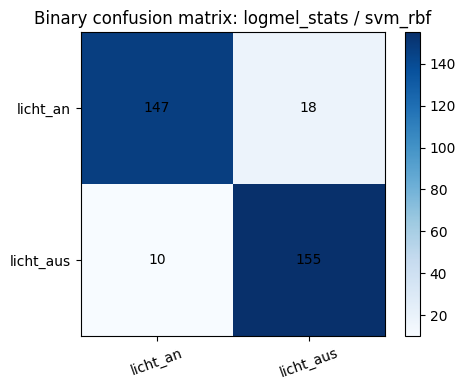

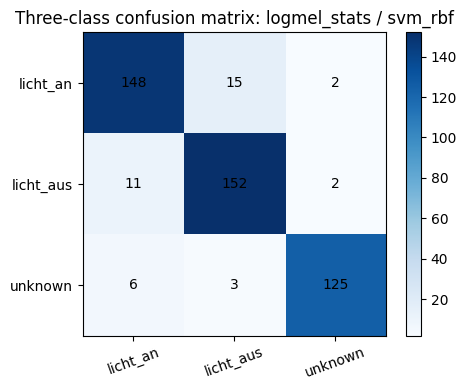

In [138]:
def plot_confusion_matrix(matrix, labels, title):
    # Zeigt, welche Klassen miteinander verwechselt werden.
    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(matrix, cmap='Blues')
    ax.set_title(title)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20)
    ax.set_yticklabels(labels)
    for row_index in range(matrix.shape[0]):
        for col_index in range(matrix.shape[1]):
            ax.text(col_index, row_index, int(matrix[row_index, col_index]), ha='center', va='center', color='black')
    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()


best_binary_details = all_details[binary_best_row['feature']][('binary', binary_best_row['model'])]
best_three_details = all_details[three_best_row['feature']][('three_class', three_best_row['model'])]

plot_confusion_matrix(
    best_binary_details['confusion_matrix'],
    [INDEX_TO_LABEL_BINARY[i] for i in sorted(INDEX_TO_LABEL_BINARY)],
    f"Binary confusion matrix: {binary_best_row['feature']} / {binary_best_row['model']}",
)
plot_confusion_matrix(
    best_three_details['confusion_matrix'],
    [INDEX_TO_LABEL_THREE[i] for i in sorted(INDEX_TO_LABEL_THREE)],
    f"Three-class confusion matrix: {three_best_row['feature']} / {three_best_row['model']}",
)


## Unknown-Verhalten

Hier pruefen wir, wie sicher oder unsicher das Modell auf unbekannte Befehle reagiert.


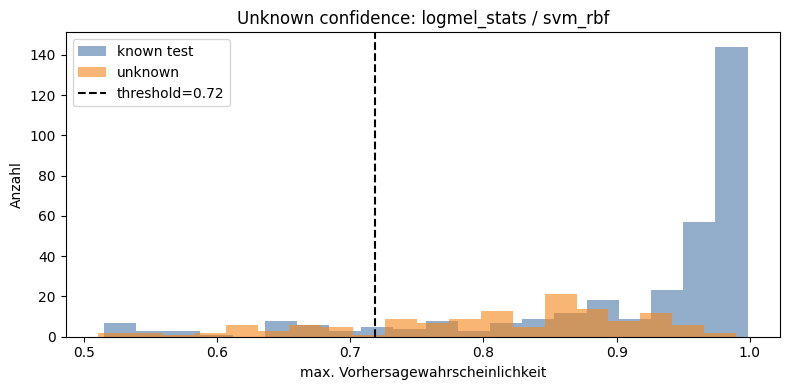

,file,predicted_label,confidence
32,Babble_9.wav,licht_an,0.989531
65,NeighborSpeaking_14.wav,licht_an,0.985770
17,AirportAnnouncements_6.wav,licht_aus,0.958099
63,NeighborSpeaking_12.wav,licht_an,0.953529
67,NeighborSpeaking_3.wav,licht_aus,0.949890
...,...,...,...
82,ShuttingDoor_5.wav,licht_aus,0.578680
94,SqueakyChair_5.wav,licht_aus,0.551546
21,Babble_1.wav,licht_an,0.536327
34,CafeTeria_1.wav,licht_an,0.516759


In [139]:
def plot_unknown_confidence(binary_details, title):
    # Schaut, ob unknown eher niedrige oder hohe Konfidenzen bekommt.
    known_conf = binary_details['known_conf']
    unknown_conf = binary_details['unknown_conf']
    threshold = binary_details['threshold']

    plt.figure(figsize=(8, 4))
    plt.hist(known_conf, bins=20, alpha=0.6, label='known test', color='#4C78A8')
    plt.hist(unknown_conf, bins=20, alpha=0.6, label='unknown', color='#F58518')
    plt.axvline(threshold, color='black', linestyle='--', label=f'threshold={threshold:.2f}')
    plt.title(title)
    plt.xlabel('max. Vorhersagewahrscheinlichkeit')
    plt.ylabel('Anzahl')
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_unknown_confidence(best_binary_details, f"Unknown confidence: {binary_best_row['feature']} / {binary_best_row['model']}")

unknown_view = pd.DataFrame(
    {
        'file': all_contexts[binary_best_row['feature']]['unknown_df']['filename'],
        'predicted_label': [INDEX_TO_LABEL_BINARY[index] for index in best_binary_details['unknown_pred']],
        'confidence': best_binary_details['unknown_conf'],
    }
)
unknown_view = unknown_view.sort_values('confidence', ascending=False)
display(unknown_view)


## Interpretation und Empfehlung

Nach dem Ausfuehren des Notebooks solltest du die Vergleichstabellen so lesen:

- Wenn das Binary-Setup deutlich besser auf den beiden Zielbefehlen ist, ist es fuer die reine Befehlsklassifikation oft die einfachere und robustere Loesung.
- Wenn das Three-Class-Setup bei unknown deutlich sauberer reagiert, ist es fuer reale Sprachsteuerung oft angenehmer, weil Fehlbefehle direkt als unknown auftauchen.
- MFCC sollte in diesem Datensatz ein sehr guter Startpunkt bleiben. Log-Mel ist die sinnvollste Alternative, weil sie die gleiche Pipeline mit einer leicht anderen Darstellung testet.

Praktisch wuerde ich das beste Modell nach zwei Kriterien auswaehlen: hohe F1 auf den Zielbefehlen und moeglichst niedrige Akzeptanz fuer unknown.


## Nächste Schritte

Wenn du willst, kann ich als Nächstes noch eins von drei Dingen ergänzen:

1. eine kleine Inferenz-Zelle zum Testen einzelner WAV-Dateien,
2. eine Export-Zelle fuer ein spaeteres Deployment,
3. oder eine schlankere Version des Notebooks nur mit dem besten Modell.


## Live-Test mit Mikrofon

In diesem Abschnitt kannst du ein Modell aus dem vorherigen Vergleich waehlen und dann direkt Audio vom Mikrofon aufnehmen, um den Befehl live zu testen.


In [140]:
import sounddevice as sd

# Hier waehlt du das Modell fuer den Live-Test aus.
# Moegliche Werte:
#   - 'binary'
#   - 'three_class'
#
# Danach setzt du das Feature-Set und den Modellnamen so, wie sie in der Ergebnistabelle erscheinen.
LIVE_TASK = 'three_class'
LIVE_FEATURE = 'logmel_stats'
LIVE_MODEL_NAME = 'svm_rbf'

# Aufnahmeparameter
LIVE_SECONDS = 1.0
LIVE_SR = SR


In [141]:
def train_best_model_for_live(task_name, feature_name, model_name):
    # Das Modell auf allen verfuegbaren Trainingsdaten neu trainieren, damit die Live-Inferenz moeglichst stabil ist.
    context = all_contexts[feature_name]
    model = make_models()[model_name]

    if task_name == 'binary':
        X_train = context['X_known']
        y_train = context['y_known']
    elif task_name == 'three_class':
        X_train = context['X_all']
        y_train = context['y_all']
    else:
        raise ValueError(f'Unbekannte Aufgabe: {task_name}')

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    return fitted_model


live_model = train_best_model_for_live(LIVE_TASK, LIVE_FEATURE, LIVE_MODEL_NAME)
print(f'Live-Modell trainiert: task={LIVE_TASK}, feature={LIVE_FEATURE}, model={LIVE_MODEL_NAME}')


Live-Modell trainiert: task=three_class, feature=logmel_stats, model=svm_rbf


In [142]:
def record_microphone(seconds=LIVE_SECONDS, sr=LIVE_SR):
    # Nimmt Audio direkt vom Standard-Mikrofon auf.
    print(f'Nehme {seconds:.1f} Sekunden vom Mikrofon auf ...')
    audio = sd.rec(int(seconds * sr), samplerate=sr, channels=1, dtype='float32')
    sd.wait()
    return audio[:, 0]


def load_audio_from_array(audio, sr=SR, target_samples=TARGET_SAMPLES):
    # Gleiche Normierung wie beim Laden aus Datei, nur eben fuer bereits aufgenommenes Audio.
    audio = np.nan_to_num(np.asarray(audio, dtype=np.float32))

    if len(audio) == 0:
        return np.zeros(target_samples, dtype=np.float32)

    if len(audio) > target_samples:
        frame = min(1024, len(audio))
        energy = np.convolve(audio ** 2, np.ones(frame, dtype=np.float32), mode='same')
        center = int(np.argmax(energy))
        start = max(0, center - target_samples // 2)
        end = start + target_samples
        if end > len(audio):
            end = len(audio)
            start = end - target_samples
        audio = audio[start:end]
    elif len(audio) < target_samples:
        audio = np.pad(audio, (0, target_samples - len(audio)))

    peak = float(np.max(np.abs(audio)))
    if peak > 0:
        audio = audio / peak

    return audio.astype(np.float32)


def classify_live_audio(audio, model, task_name, feature_name):
    # Gleiche Vorverarbeitung wie im Notebook, damit Training und Live-Test zusammenpassen.
    if len(audio) == 0:
        raise ValueError('Leeres Audiosignal aufgenommen.')

    audio = np.nan_to_num(audio).astype(np.float32)
    peak = float(np.max(np.abs(audio)))
    if peak > 0:
        audio = audio / peak

    audio = load_audio_from_array(audio, sr=LIVE_SR, target_samples=TARGET_SAMPLES)
    feature_vector = summarize_feature_map(compute_base_map(audio, feature_kind=FEATURE_SPECS[feature_name]))
    proba = model.predict_proba(feature_vector.reshape(1, -1))[0]
    predicted_index = int(np.argmax(proba))
    confidence = float(np.max(proba))

    if task_name == 'binary':
        label_map = INDEX_TO_LABEL_BINARY
    else:
        label_map = INDEX_TO_LABEL_THREE

    return {
        'predicted_label': label_map[predicted_index],
        'confidence': confidence,
        'probabilities': proba,
        'feature_vector': feature_vector,
    }


Starte in 1 Sekunden mit der Aufnahme ...
1 ...
Nehme 1.0 Sekunden vom Mikrofon auf ...


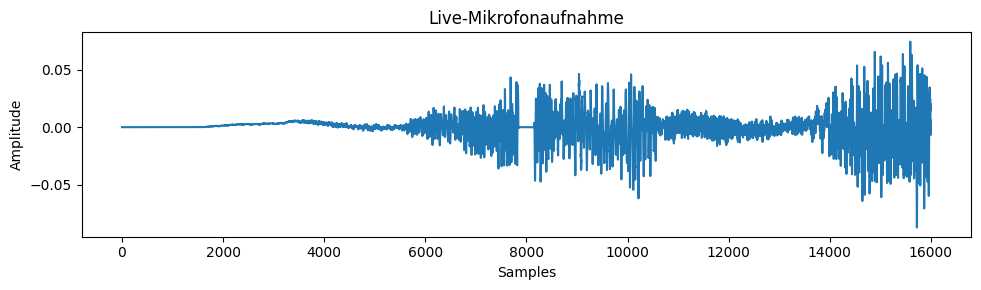

Vorhersage: licht_aus
Konfidenz: 0.7381
Wahrscheinlichkeiten: [0.172  0.7381 0.0899]


In [143]:
# Mikrofonaufnahme starten und direkt klassifizieren.
delay = 1
print(f'Starte in {delay} Sekunden mit der Aufnahme ...')
for i in range(delay, 0, -1):
    print(f'{i} ...')
    sd.sleep(1000)
recorded_audio = record_microphone()
result = classify_live_audio(recorded_audio, live_model, LIVE_TASK, LIVE_FEATURE)

plt.figure(figsize=(10, 3))
plt.plot(recorded_audio)
plt.title('Live-Mikrofonaufnahme')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

print('Vorhersage:', result['predicted_label'])
print('Konfidenz:', round(result['confidence'], 4))
print('Wahrscheinlichkeiten:', np.round(result['probabilities'], 4))


### Nutzung

1. In der Modell-Zelle `LIVE_TASK`, `LIVE_FEATURE` und `LIVE_MODEL_NAME` setzen.
2. Die Modell-Zelle ausfuehren.
3. Die Mikrofon-Zelle ausfuehren und den Befehl sprechen.

Hinweis: Falls dein Notebook keine Mikrofonrechte hat, muss die Berechtigung im Betriebssystem oder in Jupyter noch erlaubt werden.
